## Benchmark Comparison — Rolling Correlation with S&P 500

Same analysis as PCA pipeline: 252-day rolling correlation.

In [ ]:
def align_strategy_benchmark_simple(strategy_equity, df):
    """Align strategy returns with S&P 500 from local file."""
    try:
        sp = pd.read_excel("SPX_10_RISK.xls")
        sp['Date'] = pd.to_datetime(sp['Date'])
        sp = sp[['Date', 'Price']]
        sp.rename(columns={'Price': 'Close'}, inplace=True)
    except:
        print("SPX_10_RISK.xls not found. Skipping benchmark comparison.")
        return None

    sp['returns'] = np.log(sp['Close'] / sp['Close'].shift(1))
    sp.dropna(inplace=True)

    strat_returns = np.diff(strategy_equity) / strategy_equity[:-1]
    n = min(len(strat_returns), len(sp))

    return pd.DataFrame({
        "strategy": strat_returns[:n],
        "benchmark": sp['returns'].values[:n]
    })

returns_df = align_strategy_benchmark_simple(equity_hrp_mp, df)

if returns_df is not None:
    roll_corr = returns_df['strategy'].rolling(252).corr(returns_df['benchmark'])

    plt.figure(figsize=(12, 6))
    plt.plot(roll_corr, color='#1E2761', linewidth=1.2)
    plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
    plt.title("HRP (MP) — Rolling 252-Day Correlation with S&P 500", fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("Correlation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Benchmark file not available — run with SPX_10_RISK.xls in directory.")

## Summary

### Key Differences: HRP vs PCA Risk Parity

| Feature | PCA Pipeline | HRP Pipeline |
|---------|-------------|-------------|
| Covariance use | Eigen decomposition → PCA factors | Clustering on correlation distance |
| Dimensionality reduction | PCA (retain top-k eigenvectors) | Hierarchical clustering (dendrogram) |
| Weight computation | Matrix inversion (Σ⁻¹) | Recursive bisection (no inversion) |
| Weight sign | Long-short (needs regularization) | **Long-only by construction** |
| Stability | Requires ridge + explosion guard | Naturally stable |
| Key reference | Roncalli & Weisang (2012) | López de Prado (2016) |

### References
1. M. López de Prado, "Building Diversified Portfolios that Outperform Out of Sample," *J. Portfolio Management*, 2016.
2. D. Cajas, *Advanced Portfolio Optimization*, Springer, 2025.
3. T. Roncalli and G. Weisang, "Risk Parity Portfolios with Risk Factors," Working Paper, 2012.
4. O. Ledoit and M. Wolf, "A Well-Conditioned Estimator for Large-Dimensional Covariance Matrices," *J. Multivariate Anal.*, 2004.
5. V. A. Marčenko and L. A. Pastur, "Distribution of Eigenvalues for Some Sets of Random Matrices," *Math. USSR-Sbornik*, 1967.

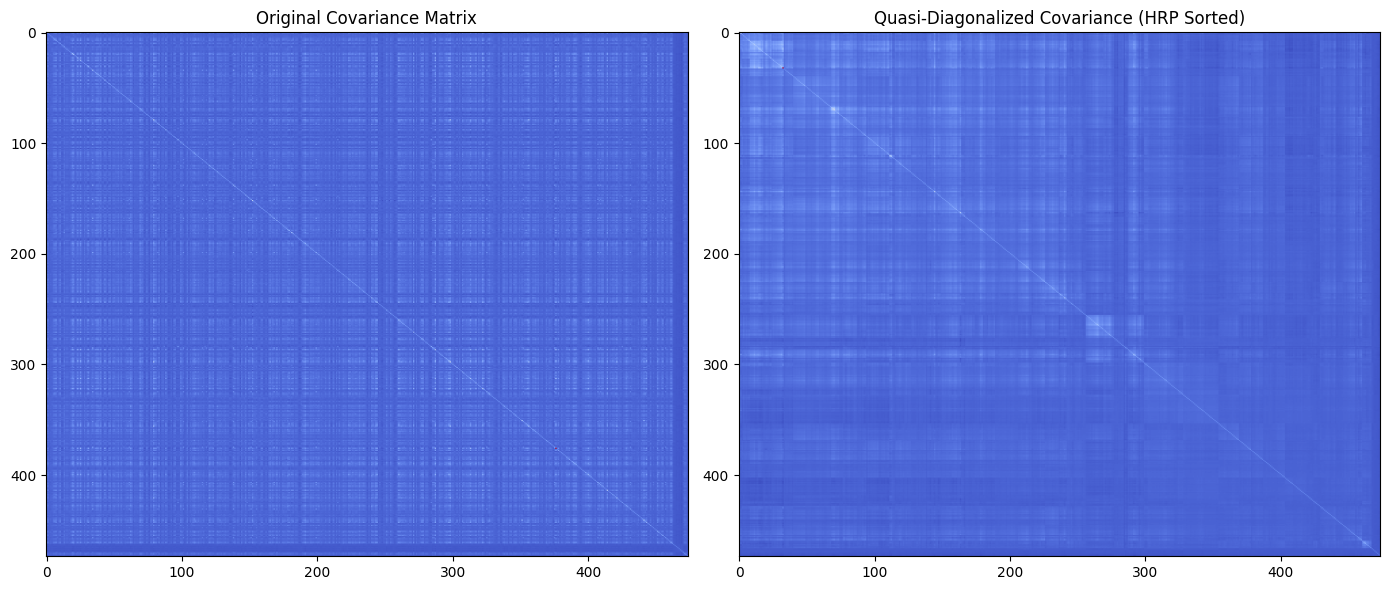

In [ ]:
# ── Compute quasi-diagonalized covariance for visualization ──
X = df.drop(columns=['Date']).values[-252*4:]   # last 4 years
X_df = pd.DataFrame(X)

# Estimate covariance
cov_df = marchenko_pastur_denoise(X_df)
cov = cov_df.values

# Correlation → clustering → leaf order
std = np.sqrt(np.diag(cov))
std[std < 1e-10] = 1e-10
corr = cov / np.outer(std, std)
corr = np.clip(corr, -1, 1)

Z = cluster_assets(corr, method='ward')
sorted_idx = quasi_diagonalize(Z, cov.shape[0])

# Quasi-diagonalized covariance
sorted_cov = cov[np.ix_(sorted_idx, sorted_idx)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cov, cmap='coolwarm', aspect='auto')
axes[0].set_title("Original Covariance Matrix")
axes[1].imshow(sorted_cov, cmap='coolwarm', aspect='auto')
axes[1].set_title("Quasi-Diagonalized Covariance (HRP Sorted)")
plt.tight_layout()
plt.show()